# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [24]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [25]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    B, C, H, W = x.shape
    assert H % patch_size == 0 and W % patch_size == 0

    # Unfold height and width
    x = x.unfold(2, patch_size, patch_size)  # (B, C, H/P, W, P)
    x = x.unfold(3, patch_size, patch_size)  # (B, C, H/P, W/P, P, P)

    # Permute and reshape
    x = x.permute(0, 2, 3, 1, 4, 5).contiguous()
    x = x.view(B, -1, C * patch_size * patch_size)

    return x

B, C, H, W = 1, 3, 4, 4
img = torch.arange(1, C*H*W + 1).view(C, H, W).repeat(B, 1, 1, 1)
patches = patchify(img, 2)
print(f"Image shape: {img.shape}, Patches shape: {patches.shape}")
print(f"Image\n{img}\n\nPatches\n{patches}")

Image shape: torch.Size([1, 3, 4, 4]), Patches shape: torch.Size([1, 4, 12])
Image
tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]],

         [[17, 18, 19, 20],
          [21, 22, 23, 24],
          [25, 26, 27, 28],
          [29, 30, 31, 32]],

         [[33, 34, 35, 36],
          [37, 38, 39, 40],
          [41, 42, 43, 44],
          [45, 46, 47, 48]]]])

Patches
tensor([[[ 1,  2,  5,  6, 17, 18, 21, 22, 33, 34, 37, 38],
         [ 3,  4,  7,  8, 19, 20, 23, 24, 35, 36, 39, 40],
         [ 9, 10, 13, 14, 25, 26, 29, 30, 41, 42, 45, 46],
         [11, 12, 15, 16, 27, 28, 31, 32, 43, 44, 47, 48]]])


In [26]:
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.ff = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return self.ff(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_tokens, d_model))  # (1, N, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_embed

In [27]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff, bias=False),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model, bias=False),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.ffn(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()

        if variant == "geglu":
            self.act = nn.GELU()
        elif variant == "reglu":
            self.act = nn.ReLU()
        else:
            raise AssertionError(f"{variant} not a valid variant!")

        self.proj_a = nn.Linear(d_model, d_ff_gated, bias=False)
        self.proj_b = nn.Linear(d_model, d_ff_gated, bias=False)
        self.dropout1 = nn.Dropout(dropout)
        self.proj_out = nn.Linear(d_ff_gated, d_model, bias=False)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        proj_a = self.proj_a(x)
        proj_b = self.proj_b(x)

        out = self.act(proj_a) * proj_b
        out = self.dropout1(out)

        out = self.proj_out(out)
        out = self.dropout2(out)

        return out

In [28]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        # TODO: implement. For attention use nn.MultiHeadAttention
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = mlp

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_norm = self.ln1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x

In [29]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # implement a strategy for embedding the patches
        self.patch_embed = PatchEmbed(patch_dim, d_model)
        self.pos_embed = PositionalEmbedding(self.num_tokens, d_model)

        # implement a strategy to select the right mlp version for your experiment
        def make_mlp() -> nn.Module:
            if mlp_kind == "ffn":
                return FeedForward(d_model, d_ff, dropout)
            else:
                d_ff_gated = d_ff * 2 // 3
                return GLUFeedForward(d_model, d_ff_gated, dropout, mlp_kind)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=make_mlp(),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # Add a head to project to the amount of output classes you have
        self.proj = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Preprocess pixels into patches and add positional embeddings
        x_patches = patchify(x, self.patch_size)
        emb = self.pos_embed(self.patch_embed(x_patches))

        # Pass embedding patches through ViT
        for block in self.blocks:
            emb = block(emb)

        # Mean pool and apply classification head
        pooled_output_emb = emb.mean(dim=1, keepdim=False)
        logits = self.proj(pooled_output_emb)
        return logits

In [30]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [31]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        "mlp_kind": mlp_kind,
        "seed": cfg.seed,
        "train_losses": train_losses,
        "test_accs": test_accs,
        "best_test_acc": max(test_accs),
    }

In [69]:
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

runs = ['ffn', 'geglu', 'reglu'] # Name your runs
results = []

seeds = range(6, 10) # evaluate 3 seeds

for seed in seeds:
    cfg = TrainConfig(seed=seed, batch_size=1024, epochs=5, lr=3e-4, weight_decay=0.01, device="cuda")

    # set the seed
    set_seed(seed)

    tfm = transforms.Compose([transforms.ToTensor()])

    train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

    # Tiny model example. TODO: You're welcome to experiment with these parameters
    patch_size = 4
    d_model = 64
    n_heads = 4
    n_layers = 2
    d_ff = 256
    dropout = 0.1

    for kind in runs:
        model = TinyViT(
            patch_size=patch_size,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff=d_ff,
            dropout=dropout,
            mlp_kind=kind,
        )
        # TODO: print anything you might want here
        print(f"\nRun: {kind} | seed: {cfg.seed}" )
        out = train_one_run(kind, model, train_loader, test_loader, cfg)
        results.append(out)


Run: ffn | seed: 6
[ffn] epoch 1/5 | test acc: 0.3860
[ffn] epoch 2/5 | test acc: 0.5792
[ffn] epoch 3/5 | test acc: 0.7253
[ffn] epoch 4/5 | test acc: 0.7871
[ffn] epoch 5/5 | test acc: 0.8257

Run: geglu | seed: 6
[geglu] epoch 1/5 | test acc: 0.3619
[geglu] epoch 2/5 | test acc: 0.6158
[geglu] epoch 3/5 | test acc: 0.7435
[geglu] epoch 4/5 | test acc: 0.8128
[geglu] epoch 5/5 | test acc: 0.8432

Run: reglu | seed: 6
[reglu] epoch 1/5 | test acc: 0.3841
[reglu] epoch 2/5 | test acc: 0.6331
[reglu] epoch 3/5 | test acc: 0.7705
[reglu] epoch 4/5 | test acc: 0.8203
[reglu] epoch 5/5 | test acc: 0.8648

Run: ffn | seed: 7
[ffn] epoch 1/5 | test acc: 0.3937
[ffn] epoch 2/5 | test acc: 0.6371
[ffn] epoch 3/5 | test acc: 0.7916
[ffn] epoch 4/5 | test acc: 0.8548
[ffn] epoch 5/5 | test acc: 0.8858

Run: geglu | seed: 7
[geglu] epoch 1/5 | test acc: 0.3796
[geglu] epoch 2/5 | test acc: 0.6315
[geglu] epoch 3/5 | test acc: 0.7886
[geglu] epoch 4/5 | test acc: 0.8316
[geglu] epoch 5/5 | test a

## Result Analysis

In [70]:
import json
import os

def dump_results_to_json(new_results: list[dict], filename: str = "experiment_results.json"):
    """Dumps new results to a JSON file, extending existing data if the file exists."""
    all_results = []
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as f:
                all_results = json.load(f)
            # Ensure it's a list, in case the file was empty or corrupted
            if not isinstance(all_results, list):
                all_results = []
        except json.JSONDecodeError: # Handle cases where file exists but is not valid JSON
            print(f"Warning: Existing file '{filename}' is not valid JSON. Overwriting.")
            all_results = [] # Start fresh if file is corrupted

    all_results.extend(new_results)

    with open(filename, 'w') as f:
        json.dump(all_results, f, indent=4)
    print(f"{len(results)} results successfully dumped to {filename}")

def load_results_from_json(filename: str = "experiment_results.json"):
    """Loads any existing results from a JSON file"""
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as f:
                all_results = json.load(f)
            # Ensure it's a list, in case the file was empty or corrupted
            if not isinstance(all_results, list):
                all_results = []

            if len(all_results) == 0:
                print(f"Warning: No results saved or saved results corrupted. Returning empty list...")
            else:
                print(f"Loaded {len(all_results)} entries from JSON.")

            return all_results

        except json.JSONDecodeError: # Handle cases where file exists but is not valid JSON
            print(f"Warning: Existing file '{filename}' is not valid JSON. Overwriting.")
            all_results = [] # Start fresh if file is corrupted
    else:
        print(f"Warning: No file named '{filename}' exists. Returning empty list...")
        return []

In [71]:
# dump_results_to_json(results, "vit_glu_ablation_results.json")

12 results successfully dumped to vit_glu_ablation_results.json


In [74]:
all_results = load_results_from_json("vit_glu_ablation_results.json")
print(f"\n{all_results[0].keys()}")
print(f"\nSeeds: {list(set([r["seed"] for r in all_results]))}")
print(f"Kinds: {list(set([r["mlp_kind"] for r in all_results]))}")
example_res = all_results[0]

Loaded 30 entries from JSON.

dict_keys(['mlp_kind', 'seed', 'train_losses', 'test_accs', 'best_test_acc'])

Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Kinds: ['geglu', 'reglu', 'ffn']


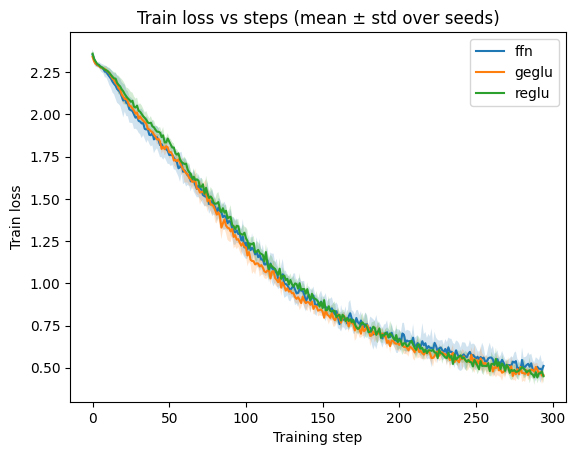

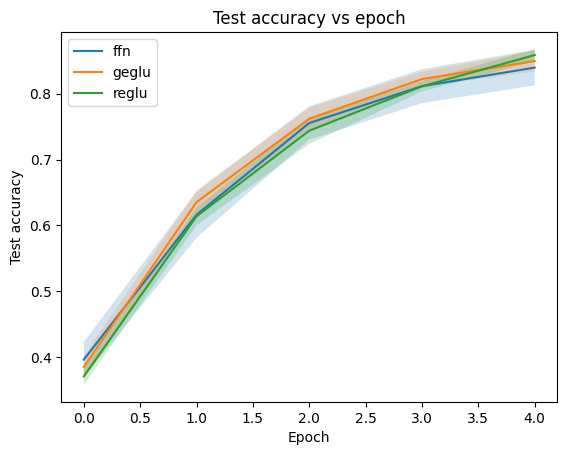

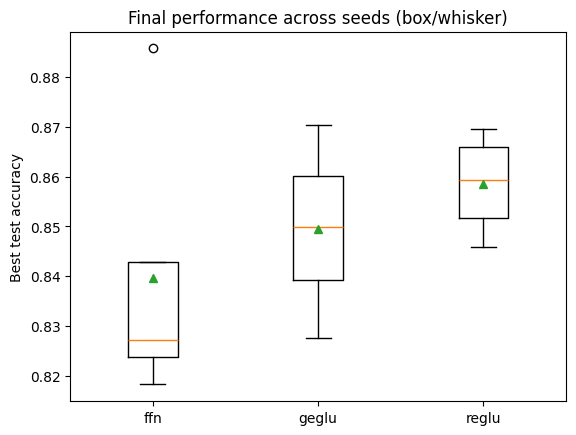

In [77]:
import matplotlib.pyplot as plt
from collections import defaultdict
import json
import os

by_kind = defaultdict(list)
for r in results:
    by_kind[r["mlp_kind"]].append(r)

# 1) Training loss vs steps
plt.figure()
for kind, runs_for_kind in by_kind.items():
    losses = np.stack([np.array(r["train_losses"]) for r in runs_for_kind], axis=0)
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)

    steps = np.arange(len(mean_loss))
    plt.plot(steps, mean_loss, label=kind)
    plt.fill_between(steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)

plt.xlabel("Training step")
plt.ylabel("Train loss")
plt.title("Train loss vs steps (mean ± std over seeds)")
plt.legend()
plt.show()

# 2) Test accuracy vs epoch
plt.figure()
for kind, runs_for_kind in by_kind.items():
    test_accs = np.stack([np.array(r["test_accs"]) for r in runs_for_kind], axis=0)
    mean_acc = test_accs.mean(axis=0)
    std_acc = test_accs.std(axis=0)

    steps = np.arange(len(mean_acc))
    plt.plot(steps, mean_acc, label=kind)
    plt.fill_between(steps, mean_acc - std_acc, mean_acc + std_acc, alpha=0.2)

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Test accuracy vs epoch")
plt.legend()
plt.show()

# 3) Box and whisker plot of best test accuracies per kind
kinds = []
data = []   # list of lists, one list per kind
for kind, runs_for_kind in by_kind.items():
    bests = [r["best_test_acc"] for r in runs_for_kind]
    kinds.append(kind)
    data.append(bests)

plt.figure()
plt.boxplot(data, tick_labels=kinds, showmeans=True)
plt.ylabel("Best test accuracy")
plt.title("Final performance across seeds (box/whisker)")
plt.show()

